# RingVoz — Minería de datos (CRISP-DM)
## Dataset de entrega para modelado: `datos/dataset_fraude_ringvoz_class_last.arff`
**Metodología:** CRISP-DM | **Fase:** Preparación de datos

**Integrantes:** José Becerra | Marleny Guiral Marín | Geraldine Suárez

## Celda 1 — Configuración e importaciones

In [31]:
import re
import os
from datetime import datetime

INPUT_PATH  = "/content/mining_data_clean.arff"
OUTPUT_PATH = "/content/dataset_fraude_ringvoz.arff"

# Lógica de fraude
# 27 = Dirección no coincide (AVS Fraud — tarjeta robada)
# 35 = Tarjeta en lista negra del procesador
# 65 = Límite de intentos superado (comportamiento de bot)
FRAUD_REASON_CODES = {27, 35, 65}
FRAUD_SUB_CODES    = {1, 2}

print('Configuración lista')
print(f'Archivo entrada : {INPUT_PATH}')
print(f'Archivo salida  : {OUTPUT_PATH}')

Configuración lista
Archivo entrada : /content/mining_data_clean.arff
Archivo salida  : /content/dataset_fraude_ringvoz.arff


## Celda 2 — Funciones auxiliares

In [ ]:
DAYS_EN = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

def parse_arff(filepath):
    attribute_names = []
    data_lines      = []
    in_data         = False
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        for line in f:
            stripped = line.strip()
            if stripped.upper() == '@DATA':
                in_data = True
                continue
            if not in_data:
                m = re.match(r'@[Aa][Tt][Tt][Rr][Ii][Bb][Uu][Tt][Ee]\s+["\']?(\w+)["\']?', stripped)
                if m:
                    attribute_names.append(m.group(1))
            else:
                if stripped and not stripped.startswith('%'):
                    data_lines.append(stripped)
    return attribute_names, data_lines


def split_arff_row(row):
    values     = []
    current    = ''
    in_quotes  = False
    quote_char = None
    for ch in row:
        if in_quotes:
            if ch == quote_char:
                in_quotes = False
            current += ch
        else:
            if ch in ('"', "'"):
                in_quotes  = True
                quote_char = ch
                current   += ch
            elif ch == ',':
                values.append(current.strip())
                current = ''
            else:
                current += ch
    values.append(current.strip())
    return values


def parse_date_v2(date_str):
    """Parsea fechas con timezone y triple comilla: \"\"\"2023-07-07 09:42:15+00:00\"\"\""""
    date_str = date_str.strip().strip('"').strip("'").strip()
    date_str = re.sub(r'[+-]\d{2}:\d{2}$', '', date_str).strip()
    formatos = [
        '%Y-%m-%d %H:%M:%S',
        '%Y-%m-%dT%H:%M:%S',
        '%Y-%m-%d %H:%M',
    ]
    for fmt in formatos:
        try:
            dt = datetime.strptime(date_str, fmt)
            return str(dt.hour), DAYS_EN[dt.weekday()]
        except ValueError:
            continue
    return '?', '?'


def calcular_is_fraud(result, respreasoncode_raw, respsubcode_raw, x_test_raw):
    try:
        if result.strip('\'" ').lower() != 'declined':
            return '0'
        reason = int(float(respreasoncode_raw.strip('\'" ')))
        if reason not in FRAUD_REASON_CODES:
            return '0'
        sub = int(float(respsubcode_raw.strip('\'" ')))
        if sub not in FRAUD_SUB_CODES:
            return '0'
        x_test = x_test_raw.strip('\'" ').lower()
        if x_test not in ('false', '0', 'no'):
            return '0'
        return '1'
    except (ValueError, AttributeError):
        return '0'


def quote_nominal(val):
    if not val or val == '?':
        return '?'
    v = val.strip('\'" ').strip()
    return f"'{v}'" if v else '?'


print('Funciones auxiliares definidas')

Funciones auxiliares definidas


## Celda 3 — Leer y explorar el archivo original

In [ ]:
print(f'Leyendo: {INPUT_PATH}')
attr_names, data_lines = parse_arff(INPUT_PATH)

print(f"\n{'='*55}")
print('  EXPLORACIÓN DEL ARCHIVO ORIGINAL')
print(f"{'='*55}")
print(f'  Total atributos : {len(attr_names)}')
print(f'  Total filas     : {len(data_lines):,}')
print(f'\n  Lista de atributos:')
for i, name in enumerate(attr_names):
    print(f'    [{i:02d}] {name}')

Leyendo: /content/mining_data_clean.arff

  EXPLORACIÓN DEL ARCHIVO ORIGINAL
  Total atributos : 24
  Total filas     : 89,890

  Lista de atributos:
    [00] Id
    [01] Result
    [02] Ref
    [03] Account_Name
    [04] Account_Type
    [05] Amount
    [06] Date_Created
    [07] Year
    [08] CRM_User
    [09] Transaction_Type
    [10] Merchant
    [11] Transaction_Use
    [12] Zip_Code
    [13] amExcludingTax
    [14] leadid
    [15] pmntGwTransId
    [16] pmntMethodId
    [17] postresult
    [18] postsent
    [19] respreasoncode
    [20] respsubcode
    [21] transusedetail
    [22] userid
    [23] x_test_request


## Celda 4 — Mapear índices y procesar filas

In [ ]:
def idx(name):
    try: return attr_names.index(name)
    except ValueError: return None

i_result   = idx('Result')
i_acct     = idx('Account_Type')
i_amount   = idx('Amount')
i_txntype  = idx('Transaction_Type')
i_merchant = idx('Merchant')
i_txnuse   = idx('Transaction_Use')
i_pmnt     = idx('pmntMethodId')
i_date     = idx('Date_Created')
i_reason   = idx('respreasoncode')
i_subcode  = idx('respsubcode')
i_xtest    = idx('x_test_request')

print('Índices mapeados:')
for name, i in [('Result',i_result),('Account_Type',i_acct),('Amount',i_amount),
                ('Transaction_Type',i_txntype),('Merchant',i_merchant),
                ('Transaction_Use',i_txnuse),('pmntMethodId',i_pmnt),
                ('Date_Created',i_date),('respreasoncode',i_reason),
                ('respsubcode',i_subcode),('x_test_request',i_xtest)]:
    status = f'[{i}]' if i is not None else '[NO ENCONTRADA]'
    print(f'  {name:25s} {status}')

Índices mapeados:
  Result                    [1]
  Account_Type              [4]
  Amount                    [5]
  Transaction_Type          [9]
  Merchant                  [10]
  Transaction_Use           [11]
  pmntMethodId              [16]
  Date_Created              [6]
  respreasoncode            [19]
  respsubcode               [20]
  x_test_request            [23]


## Celda 5 — Transformación y generación del dataset final

In [ ]:
#  Procesar filas y generar dataset final directamente con 9 variables
output_rows   = []
fraud_count   = 0
legit_count   = 0
test_skipped  = 0

for line_no, row in enumerate(data_lines, 1):
    vals = split_arff_row(row)

    def get(i):
        if i is None or i >= len(vals): return '?'
        v = vals[i].strip().strip('\'"')
        return v if v else '?'

    result   = get(i_result)
    acct     = get(i_acct)
    amount   = get(i_amount)
    txntype  = get(i_txntype)
    merchant = get(i_merchant)
    txnuse   = get(i_txnuse)
    pmnt     = get(i_pmnt)
    date_raw = vals[i_date].strip() if i_date is not None and i_date < len(vals) else '?'
    reason   = get(i_reason)
    subcode  = get(i_subcode)
    xtest    = get(i_xtest)

    # Filtrar transacciones de prueba
    if xtest.lower() in ('true', '1', 'yes'):
        test_skipped += 1
        continue

    # Calcular is_fraud ANTES de descartar columnas
    is_fraud = calcular_is_fraud(result, reason, subcode, xtest)
    if is_fraud == '1': fraud_count += 1
    else: legit_count += 1

    # Extraer hora y día
    hour_of_day, day_of_week = parse_date_v2(date_raw)

    # Dataset final con 9 variables (sin Result, Zip_Code, transusedetail)
    row_out = [
        quote_nominal(acct),      # [0] Account_Type
        amount,                    # [1] Amount
        quote_nominal(txntype),   # [2] Transaction_Type
        quote_nominal(merchant),  # [3] Merchant
        quote_nominal(txnuse),    # [4] Transaction_Use
        pmnt,                      # [5] pmntMethodId
        quote_nominal(is_fraud),  # [6] is_fraud
        hour_of_day,               # [7] hour_of_day
        quote_nominal(day_of_week), # [8] day_of_week
    ]
    output_rows.append(','.join(row_out))

#  Guardar archivo ARFF final
DEST_HEADER_FINAL = """@relation dataset_fraude_ringvoz

@ATTRIBUTE Account_Type     {'Retail','Corporate','Merchant','Not Defined'}
@ATTRIBUTE Amount           NUMERIC
@ATTRIBUTE Transaction_Type {'Recharge from IVR','Recharge from APM','Mobile App Recharge','Automatic Recharge','Merchant Recharge','RingVoz Website Recharge','Recharge iSMS','Activation Recharge','Monthly Recurrent Charge','Twixtext Recharge'}
@ATTRIBUTE Merchant         {'Authorize.Net 2 [Nr. 1469355]','Stripe','Cash','Wallet'}
@ATTRIBUTE Transaction_Use  {'Balance Recharge','Gift Card Recharge','Internet Nauta Recharge','Intl Mobile Recharge','Invoice Payment','Multiple Recharge','Plan Payment','Twixtext Recharge'}
@ATTRIBUTE pmntMethodId     NUMERIC
@ATTRIBUTE is_fraud         {'0','1'}
@ATTRIBUTE hour_of_day      NUMERIC
@ATTRIBUTE day_of_week      {'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'}

@DATA"""

with open(OUTPUT_PATH, 'w', encoding='utf-8') as f:
    f.write(DEST_HEADER_FINAL)
    f.write('\n')
    for r in output_rows:
        f.write(r + '\n')

total = fraud_count + legit_count
print(f"{'='*55}")
print(f'  DATASET FINAL — {OUTPUT_PATH}')
print(f"{'='*55}")
print(f'  Variables        : 9')
print(f'  Registros        : {total:,}')
print(f'  Legítimas        : {legit_count:,}')
print(f'  Fraudes          : {fraud_count:,}')
print(f'  % Fraude         : {fraud_count/total*100:.2f}%')
print(f'  Prueba excluidas : {test_skipped:,}')
print(f"{'='*55}")
print(f'\nEstructura final:')
primera = split_arff_row(output_rows[0])
atributos = ['Account_Type','Amount','Transaction_Type','Merchant',
             'Transaction_Use','pmntMethodId','is_fraud','hour_of_day','day_of_week']
for i, (attr, val) in enumerate(zip(atributos, primera)):
    print(f'  [{i}] {attr:<20} = {val}')

  DATASET FINAL — /content/dataset_fraude_ringvoz.arff
  Variables        : 9
  Registros        : 89,890
  Legítimas        : 89,873
  Fraudes          : 17
  % Fraude         : 0.02%
  Prueba excluidas : 0

Estructura final:
  [0] Account_Type         = 'Retail'
  [1] Amount               = 21.4
  [2] Transaction_Type     = 'Recharge from IVR'
  [3] Merchant             = 'Authorize.Net 2 [Nr. 1469355]'
  [4] Transaction_Use      = 'Balance Recharge'
  [5] pmntMethodId         = 1
  [6] is_fraud             = '0'
  [7] hour_of_day          = 9
  [8] day_of_week          = 'Friday'


## Celda 6 — 3.3 Descripción Estadística

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

#  Calcular conteos con índices correctos del dataset final
# Índices: [0]Account_Type [1]Amount [2]Txn_Type [3]Merchant
#          [4]Txn_Use [5]pmntMethodId [6]is_fraud [7]hour_of_day [8]day_of_week
amounts, pmnt_ids, hours = [], [], []
acct_counts     = {}
txntype_counts  = {}
merchant_counts = {}
txnuse_counts   = {}
fraud_counts    = {'0': 0, '1': 0}
dow_counts      = {}

for row in output_rows:
    vals = split_arff_row(row)
    def gv(i):
        return vals[i].strip().strip('\'"') if i < len(vals) else '?'

    acct_counts[gv(0)]     = acct_counts.get(gv(0), 0) + 1
    txntype_counts[gv(2)]  = txntype_counts.get(gv(2), 0) + 1
    merchant_counts[gv(3)] = merchant_counts.get(gv(3), 0) + 1
    txnuse_counts[gv(4)]   = txnuse_counts.get(gv(4), 0) + 1
    fraud_counts[gv(6)]    = fraud_counts.get(gv(6), 0) + 1
    dow_counts[gv(8)]      = dow_counts.get(gv(8), 0) + 1

    try: amounts.append(float(gv(1)))
    except: pass
    try: pmnt_ids.append(float(gv(5)))
    except: pass
    try: hours.append(float(gv(7)))
    except: pass

result_counts = {'Approved': fraud_counts.get('0',0), 'Declined/Fraude': fraud_counts.get('1',0)}

print(f' Conteos calculados')
print(f'   Total amounts  : {len(amounts):,}')
print(f'   Total hours    : {len(hours):,}')
print(f'   fraud_counts   : {fraud_counts}')
print(f'   acct_counts    : {acct_counts}')

 Conteos calculados
   Total amounts  : 89,890
   Total hours    : 89,890
   fraud_counts   : {'0': 89873, '1': 17}
   acct_counts    : {'Retail': 87847, 'Corporate': 941, 'Merchant': 1098, 'Not Defined': 4}


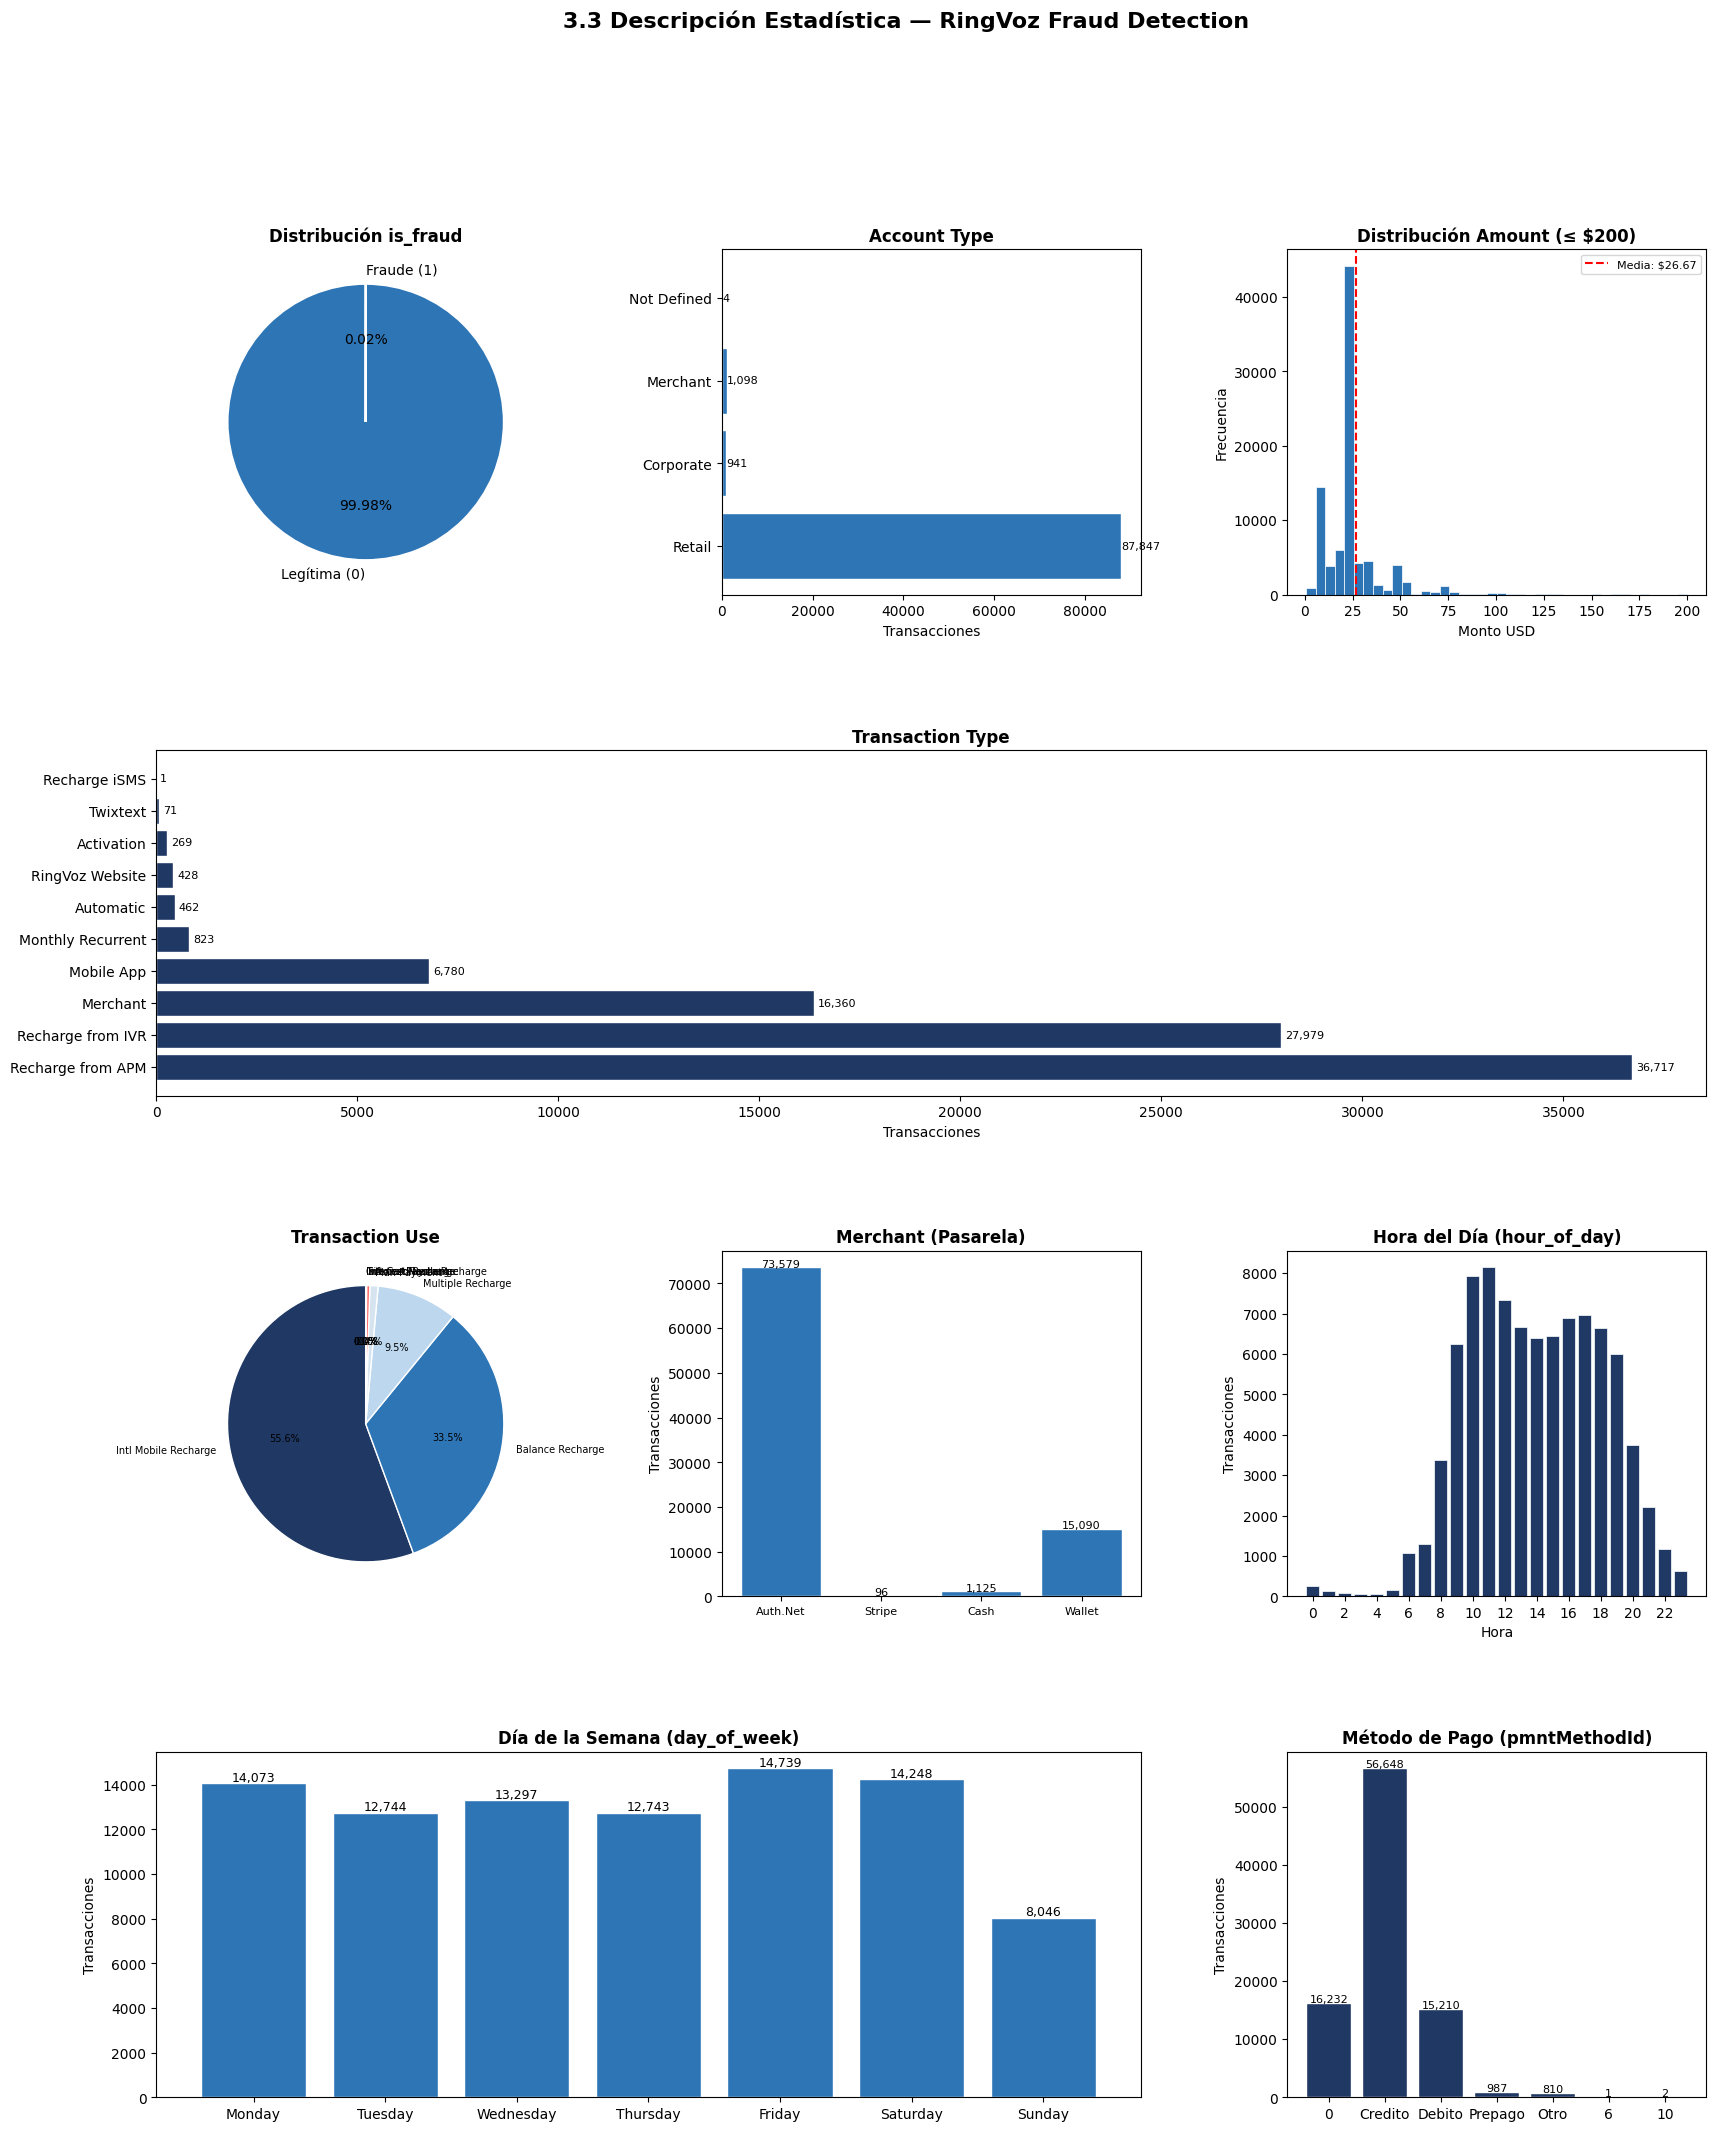

Gráfico guardado: /content/estadistica_descriptiva_ringvoz.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================
# GRÁFICAS DESCRIPTIVAS
# =========================

fig = plt.figure(figsize=(20, 24))

fig.suptitle(
    '3.3 Descripción Estadística — RingVoz Fraud Detection',
    fontsize=16,
    fontweight='bold',
    y=0.98
)

gs = gridspec.GridSpec(
    4,
    3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

# =========================
# 1. is_fraud
# =========================
ax1 = fig.add_subplot(gs[0, 0])

fraud_labels = ['Legítima (0)', 'Fraude (1)']
fraud_vals = [
    fraud_counts.get('0', 0),
    fraud_counts.get('1', 0)
]

ax1.pie(
    fraud_vals,
    labels=fraud_labels,
    colors=['#2E75B6', '#FF6B6B'],
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.5
    }
)

ax1.set_title(
    'Distribución is_fraud',
    fontweight='bold'
)

# =========================
# 2. Account_Type
# =========================
ax2 = fig.add_subplot(gs[0, 1])

at_labels = list(acct_counts.keys())
at_values = list(acct_counts.values())

bars = ax2.barh(
    at_labels,
    at_values,
    color='#2E75B6',
    edgecolor='white'
)

ax2.set_title(
    'Account Type',
    fontweight='bold'
)

ax2.set_xlabel('Transacciones')

for bar, v in zip(bars, at_values):
    ax2.text(
        v + 100,
        bar.get_y() + bar.get_height()/2,
        f'{v:,}',
        va='center',
        fontsize=8
    )

# =========================
# 3. Amount histograma
# =========================
ax3 = fig.add_subplot(gs[0, 2])

amounts_f = [a for a in amounts if 0 < a <= 200]

ax3.hist(
    amounts_f,
    bins=40,
    color='#2E75B6',
    edgecolor='white',
    linewidth=0.5
)

ax3.set_title(
    'Distribución Amount (≤ $200)',
    fontweight='bold'
)

ax3.set_xlabel('Monto USD')
ax3.set_ylabel('Frecuencia')

if len(amounts) > 0:
    media = sum(amounts) / len(amounts)

    ax3.axvline(
        media,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Media: ${media:.2f}'
    )

    ax3.legend(fontsize=8)

# =========================
# 4. Transaction_Type
# =========================
ax4 = fig.add_subplot(gs[1, :])

tt_sorted = sorted(
    txntype_counts.items(),
    key=lambda x: -x[1]
)

tt_labels = [
    k.replace(' Recharge', '')
     .replace('Monthly Recurrent Charge', 'Monthly Recurrent')
    for k, _ in tt_sorted
]

tt_values = [v for _, v in tt_sorted]

bars = ax4.barh(
    tt_labels,
    tt_values,
    color='#1F3864',
    edgecolor='white'
)

ax4.set_title(
    'Transaction Type',
    fontweight='bold'
)

ax4.set_xlabel('Transacciones')

for bar, v in zip(bars, tt_values):
    ax4.text(
        v + 100,
        bar.get_y() + bar.get_height()/2,
        f'{v:,}',
        va='center',
        fontsize=8
    )

# =========================
# 5. Transaction_Use
# =========================
ax5 = fig.add_subplot(gs[2, 0])

tu_sorted = sorted(
    txnuse_counts.items(),
    key=lambda x: -x[1]
)

tu_labels = [k for k, _ in tu_sorted]
tu_values = [v for _, v in tu_sorted]

ax5.pie(
    tu_values,
    labels=tu_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=[
        '#1F3864',
        '#2E75B6',
        '#BDD7EE',
        '#D6E4F0',
        '#FF6B6B',
        '#FFA07A',
        '#90EE90',
        '#FFD700'
    ],
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1
    }
)

for text in ax5.texts:
    text.set_fontsize(7)

ax5.set_title(
    'Transaction Use',
    fontweight='bold'
)

# =========================
# 6. Merchant
# =========================
ax6 = fig.add_subplot(gs[2, 1])

m_labels = list(merchant_counts.keys())
m_values = list(merchant_counts.values())

ax6.bar(
    range(len(m_labels)),
    m_values,
    color='#2E75B6',
    edgecolor='white'
)

ax6.set_title(
    'Merchant (Pasarela)',
    fontweight='bold'
)

ax6.set_ylabel('Transacciones')

ax6.set_xticks(range(len(m_labels)))

ax6.set_xticklabels(
    [
        l.replace(
            'Authorize.Net 2 [Nr. 1469355]',
            'Auth.Net'
        )
        for l in m_labels
    ],
    fontsize=8
)

for i, v in enumerate(m_values):
    ax6.text(
        i,
        v + 100,
        f'{v:,}',
        ha='center',
        fontsize=8
    )

# =========================
# 7. hour_of_day
# =========================
ax7 = fig.add_subplot(gs[2, 2])

hour_counts = {}

for h in hours:
    k = int(h)
    hour_counts[k] = hour_counts.get(k, 0) + 1

hkeys = sorted(hour_counts.keys())
hvals = [hour_counts[k] for k in hkeys]

ax7.bar(
    hkeys,
    hvals,
    color='#1F3864',
    edgecolor='white',
    linewidth=0.5
)

ax7.set_title(
    'Hora del Día (hour_of_day)',
    fontweight='bold'
)

ax7.set_xlabel('Hora')
ax7.set_ylabel('Transacciones')

ax7.set_xticks(range(0, 24, 2))

# =========================
# 8. day_of_week
# =========================
ax8 = fig.add_subplot(gs[3, 0:2])

orden_dias = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

dow_vals = [
    dow_counts.get(d, 0)
    for d in orden_dias
]

bars = ax8.bar(
    orden_dias,
    dow_vals,
    color='#2E75B6',
    edgecolor='white'
)

ax8.set_title(
    'Día de la Semana (day_of_week)',
    fontweight='bold'
)

ax8.set_ylabel('Transacciones')

for bar, v in zip(bars, dow_vals):
    ax8.text(
        bar.get_x() + bar.get_width()/2,
        v + 100,
        f'{v:,}',
        ha='center',
        fontsize=9
    )

# =========================
# 9. pmntMethodId
# =========================
ax9 = fig.add_subplot(gs[3, 2])

pmnt_counts = {}

for p in pmnt_ids:
    k = int(p)
    pmnt_counts[k] = pmnt_counts.get(k, 0) + 1

metodos = {
    1: 'Credito',
    2: 'Debito',
    3: 'Prepago',
    4: 'Otro',
    5: 'Otro2'
}

pm_labels = [
    metodos.get(k, str(k))
    for k in sorted(pmnt_counts.keys())
]

pm_values = [
    pmnt_counts[k]
    for k in sorted(pmnt_counts.keys())
]

ax9.bar(
    pm_labels,
    pm_values,
    color='#1F3864',
    edgecolor='white'
)

ax9.set_title(
    'Método de Pago (pmntMethodId)',
    fontweight='bold'
)

ax9.set_ylabel('Transacciones')

for i, v in enumerate(pm_values):
    ax9.text(
        i,
        v + 100,
        f'{v:,}',
        ha='center',
        fontsize=8
    )

# =========================
# GUARDAR Y MOSTRAR
# =========================
plt.savefig(
    '/content/estadistica_descriptiva_ringvoz.png',
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print('Gráfico guardado: /content/estadistica_descriptiva_ringvoz.png')

# =========================
# DESCARGAR AUTOMÁTICAMENTE
# =========================
from google.colab import files

files.download('/content/estadistica_descriptiva_ringvoz.png')

## Celda 7 — 3.5 Limpieza de Nulos

In [ ]:
print('='*60)
print('  3.5 LIMPIEZA DE NULOS — Variables seleccionadas')
print('='*60)

vars_finales = [
    (0, 'Account_Type',     'Categorica'),
    (1, 'Amount',           'Numerica'),
    (2, 'Transaction_Type', 'Categorica'),
    (3, 'Merchant',         'Categorica'),
    (4, 'Transaction_Use',  'Categorica'),
    (5, 'pmntMethodId',     'Numerica'),
    (6, 'is_fraud',         'Binaria'),
    (7, 'hour_of_day',      'Numerica'),
    (8, 'day_of_week',      'Categorica'),
]

total = len(output_rows)
print(f'\n  Total registros: {total:,}')
print(f'  Umbral nulos   : 15%')
print(f"\n  {'Variable':<20} {'Tipo':<12} {'Nulos':>8} {'%':>8}  {'Accion'}")
print(f"  {'-'*70}")

for col_idx, nombre, tipo in vars_finales:
    nulos = sum(
        1 for row in output_rows
        if split_arff_row(row)[col_idx].strip() in ('?', '', "''", '""')
    )
    pct = nulos / total * 100
    if pct > 15: accion = 'ELIMINAR VARIABLE'
    elif pct > 0 and tipo == 'Numerica': accion = 'Imputar por media/mediana'
    elif pct > 0 and tipo in ('Categorica', 'Binaria'): accion = 'Imputar por moda'
    else: accion = 'OK — sin nulos'
    print(f"  {nombre:<20} {tipo:<12} {nulos:>8,} {pct:>7.2f}%  {accion}")

  3.5 LIMPIEZA DE NULOS — Variables seleccionadas

  Total registros: 89,890
  Umbral nulos   : 15%

  Variable             Tipo            Nulos        %  Accion
  ----------------------------------------------------------------------
  Account_Type         Categorica          0    0.00%  OK — sin nulos
  Amount               Numerica            0    0.00%  OK — sin nulos
  Transaction_Type     Categorica          0    0.00%  OK — sin nulos
  Merchant             Categorica          0    0.00%  OK — sin nulos
  Transaction_Use      Categorica          0    0.00%  OK — sin nulos
  pmntMethodId         Numerica            0    0.00%  OK — sin nulos
  is_fraud             Binaria             0    0.00%  OK — sin nulos
  hour_of_day          Numerica            0    0.00%  OK — sin nulos
  day_of_week          Categorica          0    0.00%  OK — sin nulos


## Celda 8 — 3.6 y 3.7 Análisis de Correlaciones

r = +1 -> cuando una sube, la otra sube dentro de la misma proporción
r = -1 -> cuando una sube, la otra baja
R = 0 -> NO HAY una relación lineal

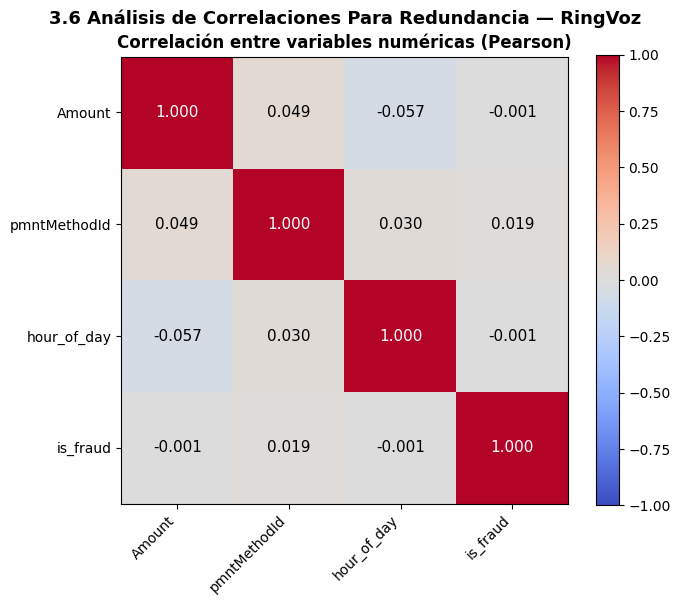

 Guardado: 3_6_redundancia_ringvoz.png

  3.6 CORRELACIÓN PARA REDUNDANCIA (Pearson)
  Amount — pmntMethodId              : r = 0.0487  - SIN REDUNDANCIA
  Amount — hour_of_day               : r = -0.0570  - SIN REDUNDANCIA
  pmntMethodId — hour_of_day         : r = 0.0302  - SIN REDUNDANCIA


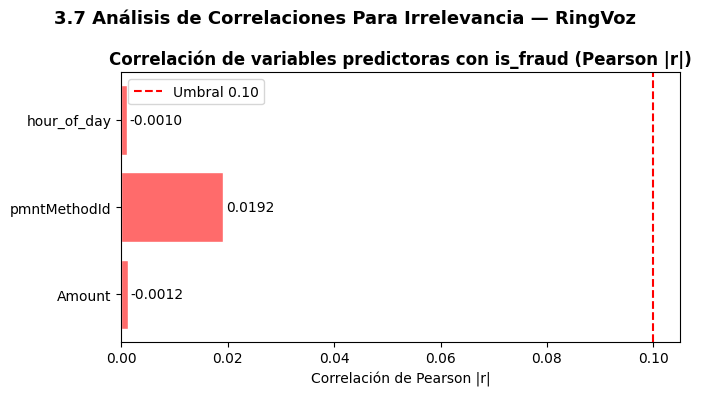

 Guardado: 3_7_irrelevancia_ringvoz.png

  3.7 CORRELACIÓN PARA IRRELEVANCIA (con is_fraud)
  Amount         : r = -0.0012  - BAJA CORRELACION LINEAL — conservar
  pmntMethodId   : r = 0.0192  - BAJA CORRELACION LINEAL — conservar
  hour_of_day    : r = -0.0010  - BAJA CORRELACION LINEAL — conservar


In [33]:
#  Extraer valores numéricos del dataset final
import os
from pathlib import Path
try:
    BASE_PATH
except NameError:
    BASE_PATH = str(Path.cwd()).rstrip(os.sep) + os.sep

amounts_c, pmnt_c, hours_c, fraud_c = [], [], [], []
for row in output_rows:
    vals = split_arff_row(row)
    def gv(i): return vals[i].strip().strip('\'"') if i < len(vals) else '?'
    try: amounts_c.append(float(gv(1)))
    except: amounts_c.append(0.0)
    try: pmnt_c.append(float(gv(5)))
    except: pmnt_c.append(0.0)
    try: hours_c.append(float(gv(7)))
    except: hours_c.append(0.0)
    try: fraud_c.append(float(gv(6)))
    except: fraud_c.append(0.0)

data_matrix = np.array([amounts_c, pmnt_c, hours_c, fraud_c])
labels      = ['Amount', 'pmntMethodId', 'hour_of_day', 'is_fraud']
corr_matrix = np.corrcoef(data_matrix)
vars_num    = ['Amount', 'pmntMethodId', 'hour_of_day']
corr_fraud  = [corr_matrix[3][0], corr_matrix[3][1], corr_matrix[3][2]]

#  Gráfico 3.6 Redundancia
fig1, ax1 = plt.subplots(figsize=(7, 6))
fig1.suptitle('3.6 Análisis de Correlaciones Para Redundancia — RingVoz',
              fontsize=13, fontweight='bold')
im = ax1.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_xticks(range(len(labels)))
ax1.set_yticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=45, ha='right')
ax1.set_yticklabels(labels)
ax1.set_title('Correlación entre variables numéricas (Pearson)', fontweight='bold')
plt.colorbar(im, ax=ax1)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax1.text(j, i, f'{corr_matrix[i,j]:.3f}', ha='center', va='center',
                fontsize=11, color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')
fig1.tight_layout()
fig1.savefig(BASE_PATH + '3_6_redundancia_ringvoz.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(' Guardado: 3_6_redundancia_ringvoz.png')

print(f"\n{'='*65}")
print('  3.6 CORRELACIÓN PARA REDUNDANCIA (Pearson)')
print(f"{'='*65}")
pares = [
    ('Amount — pmntMethodId',      corr_matrix[0][1]),
    ('Amount — hour_of_day',       corr_matrix[0][2]),
    ('pmntMethodId — hour_of_day', corr_matrix[1][2]),
]
for par, r in pares:
    estado = 'SIN REDUNDANCIA' if abs(r) < 0.10 else 'POSIBLE REDUNDANCIA'
    print(f'  {par:<35}: r = {r:.4f}  - {estado}')

#  Gráfico 3.7 Irrelevancia
fig2, ax2 = plt.subplots(figsize=(7, 4))
fig2.suptitle('3.7 Análisis de Correlaciones Para Irrelevancia — RingVoz',
              fontsize=13, fontweight='bold')
colors = ['#2E75B6' if abs(c) > 0.1 else '#FF6B6B' for c in corr_fraud]
bars = ax2.barh(vars_num, [abs(c) for c in corr_fraud], color=colors, edgecolor='white')
ax2.set_title('Correlación de variables predictoras con is_fraud (Pearson |r|)', fontweight='bold')
ax2.set_xlabel('Correlación de Pearson |r|')
ax2.axvline(0.1, color='red', linestyle='--', linewidth=1.5, label='Umbral 0.10')
ax2.legend()
for bar, c in zip(bars, corr_fraud):
    ax2.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
             f'{c:.4f}', va='center', fontsize=10)
fig2.tight_layout()
fig2.savefig(BASE_PATH + '3_7_irrelevancia_ringvoz.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(' Guardado: 3_7_irrelevancia_ringvoz.png')

print(f"\n{'='*65}")
print('  3.7 CORRELACIÓN PARA IRRELEVANCIA (con is_fraud)')
print(f"{'='*65}")
for var, c in zip(vars_num, corr_fraud):
    estado = 'RELEVANTE' if abs(c) > 0.1 else 'BAJA CORRELACION LINEAL — conservar'
    print(f'  {var:<15}: r = {c:.4f}  - {estado}')